In [1]:
from aoespy import *
import xarray as xr
dir='/nobackupp27/afahad/exp/'
data='/nobackupp27/afahad/project/initialization_shock/data/'

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm

def plot_xr(data_array, lon, lat, ax=None, **kwargs):
    """
    Creates a map plot for an xarray DataArray using Cartopy.
    This function is optimized for speed using pcolormesh and is
    compatible with subplots.

    Args:
        data_array (xr.DataArray): The 2D xarray DataArray to plot.
        lon (xr.DataArray or np.ndarray): 1D or 2D array of longitude values.
        lat (xr.DataArray or np.ndarray): 1D or 2D array of latitude values.
        ax (matplotlib.axes.Axes, optional): The axes object to plot on.
                                             If None, a new figure and axes are created.
                                             Default: None.
        **kwargs: Optional keyword arguments for customization.
            projection_style (str): 'mercator', 'robinson', 'mollweide', 'orthographic'.
                                    Default: 'mercator'.
            cmap (str or Colormap): The colormap for the plot. Default: 'viridis'.
            levels (list or int): A list of discrete levels for color mapping.
                                  Required for discrete colorbars. Default: 11.
            title (str): The title for the plot. Default: ''.
            cbar_label (str): The label for the colorbar. Default: ''.
            add_coastlines (bool): Whether to add coastlines. Default: True.
            add_borders (bool): Whether to add country borders. Default: False.
            add_land (bool): Whether to add a land mask. Default: False.
            add_gridlines (bool): Whether to add gridlines. Default: True.
            central_longitude (float): The central longitude for the projection. Default: 0.
            central_latitude (float): The central latitude for 'orthographic'. Default: 0.
    """
    # --- 1. Deconstruct keyword arguments ---
    projection_style = kwargs.get('projection_style', 'mercator').lower()
    central_longitude = kwargs.get('central_longitude', 0)
    central_latitude = kwargs.get('central_latitude', 0)
    cmap = kwargs.get('cmap', 'viridis')
    levels = kwargs.get('levels', 11)
    title = kwargs.get('title', 'Cartopy Plot')
    cbar_label = kwargs.get('cbar_label', '')
    add_coastlines = kwargs.get('add_coastlines', True)
    add_borders = kwargs.get('add_borders', False)
    add_land = kwargs.get('add_land', False)
    add_gridlines = kwargs.get('add_gridlines', True)

    # --- 2. Select the map projection ---
    proj_map = {
        'robinson': ccrs.Robinson,
        'mercator': ccrs.Mercator,
        'mollweide': ccrs.Mollweide,
        'orthographic': ccrs.Orthographic
    }
    proj_class = proj_map.get(projection_style, ccrs.Mercator)
    if projection_style == 'orthographic':
        projection = proj_class(central_longitude=central_longitude, central_latitude=central_latitude)
    else:
        projection = proj_class(central_longitude=central_longitude)

    # --- 3. Handle Axes for Subplot Compatibility ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': projection})
    else:
        fig = ax.get_figure()

    # --- 4. Plot the data using pcolormesh for performance ---
    norm = None
    if isinstance(levels, (list, np.ndarray)):
        # Get a colormap object with the correct number of colors
        cmap_obj = plt.get_cmap(cmap, len(levels) - 1)
        # Create a BoundaryNorm for discrete color mapping
        norm = BoundaryNorm(levels, ncolors=cmap_obj.N, clip=True)
    else:
        cmap_obj = plt.get_cmap(cmap)

#     im = ax.pcolormesh(
#         lon, lat, data_array,
#         cmap=cmap_obj,
#         norm=norm,
#         transform=ccrs.PlateCarree()
#     )
    im = ax.contourf(
        lon, lat, data_array,
        cmap=cmap_obj,
        norm=norm,
        transform=ccrs.PlateCarree(),
        levels=levels,
        extend='both'
    )

    # --- 5. Add geographic features ---
    if add_land:
        ax.add_feature(cfeature.LAND, zorder=1, edgecolor='k', facecolor='beige')
    if add_coastlines:
        ax.add_feature(cfeature.COASTLINE)
    if add_borders:
        ax.add_feature(cfeature.BORDERS, linestyle=':')
    if add_gridlines:
        gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False

    # --- 6. Add colorbar and title ---
    # Create the colorbar on the figure to avoid subplot size issues
    #cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    #if isinstance(levels, (list, np.ndarray)):
        #cbar.set_ticks(levels)
    #cbar.set_label(cbar_label, fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_global()

In [4]:
RP416=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0416/holding/geosgcm_prog/200504/*prog*200504*z.nc4').OMEGA.sel(lev=500)
RP421=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0421/holding/geosgcm_prog/200504/*prog*200504*z.nc4').OMEGA.sel(lev=500)
RP426=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0426/holding/geosgcm_prog/200504/*prog*200504*z.nc4').OMEGA.sel(lev=500)
RP506=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_prog/200505/*prog*200505*z.nc4').OMEGA.sel(lev=500)
RP511=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0511/holding/geosgcm_prog/200505/*prog*200505*z.nc4').OMEGA.sel(lev=500)

In [5]:
RP4162=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0416/holding/geosgcm_prog/200505/*prog*200505*z.nc4').OMEGA.sel(lev=500)
RP4212=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0421/holding/geosgcm_prog/200505/*prog*200505*z.nc4').OMEGA.sel(lev=500)
RP4262=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0426/holding/geosgcm_prog/200505/*prog*200505*z.nc4').OMEGA.sel(lev=500)
RP5062=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_prog/200506/*prog*200506*z.nc4').OMEGA.sel(lev=500)
RP5112=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0511/holding/geosgcm_prog/200506/*prog*200506*z.nc4').OMEGA.sel(lev=500)

In [6]:
RP4163=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0416/holding/geosgcm_prog/200506/*prog*200506*z.nc4').OMEGA.sel(lev=500)
RP4213=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0421/holding/geosgcm_prog/200506/*prog*200506*z.nc4').OMEGA.sel(lev=500)
RP4263=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0426/holding/geosgcm_prog/200506/*prog*200506*z.nc4').OMEGA.sel(lev=500)
RP5063=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_prog/200507/*prog*200507*z.nc4').OMEGA.sel(lev=500)
RP5113=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0511/holding/geosgcm_prog/200507/*prog*200507*z.nc4').OMEGA.sel(lev=500)

In [7]:
RP4161=xr.concat([RP416,RP4162,RP4163],dim='time')
RP4211=xr.concat([RP421,RP4212,RP4213],dim='time')
RP426=xr.concat([RP426,RP4262,RP4263],dim='time')
RP506=xr.concat([RP506,RP5062,RP5063],dim='time')
RP511=xr.concat([RP511,RP5112,RP5113],dim='time')

In [8]:
RP416P=(RP4161).compute()
RP421P=(RP4211).compute()
RP426P=(RP426).compute()
RP506P=(RP506).compute()
RP511P=(RP511).compute()

In [9]:
ME416=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0416/holding/geosgcm_prog/200504/*prog*200504*z.nc4').OMEGA.sel(lev=500)
ME421=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0421/holding/geosgcm_prog/200504/*prog*200504*z.nc4').OMEGA.sel(lev=500)
ME426=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0426/holding/geosgcm_prog/200504/*prog*200504*z.nc4').OMEGA.sel(lev=500)
ME506=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_prog/200505/*prog*200505*z.nc4').OMEGA.sel(lev=500)
ME511=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0511/holding/geosgcm_prog/200505/*prog*200505*z.nc4').OMEGA.sel(lev=500)

ME4162=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0416/holding/geosgcm_prog/200505/*prog*200505*z.nc4').OMEGA.sel(lev=500)
ME4212=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0421/holding/geosgcm_prog/200505/*prog*200505*z.nc4').OMEGA.sel(lev=500)
ME4262=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0426/holding/geosgcm_prog/200505/*prog*200505*z.nc4').OMEGA.sel(lev=500)
ME5062=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_prog/200506/*prog*200506*z.nc4').OMEGA.sel(lev=500)
ME5112=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0511/holding/geosgcm_prog/200506/*prog*200506*z.nc4').OMEGA.sel(lev=500)

ME4163=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0416/holding/geosgcm_prog/200506/*prog*200506*z.nc4').OMEGA.sel(lev=500)
ME4213=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0421/holding/geosgcm_prog/200506/*prog*200506*z.nc4').OMEGA.sel(lev=500)
ME4263=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0426/holding/geosgcm_prog/200506/*prog*200506*z.nc4').OMEGA.sel(lev=500)
ME5063=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_prog/200507/*prog*200507*z.nc4').OMEGA.sel(lev=500)
ME5113=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0511/holding/geosgcm_prog/200507/*prog*200507*z.nc4').OMEGA.sel(lev=500)




In [10]:
ME4161=xr.concat([ME416,ME4162,ME4163],dim='time')
ME4211=xr.concat([ME421,ME4212,ME4213],dim='time')
ME426=xr.concat([ME426,ME4262,ME4263],dim='time')
ME506=xr.concat([ME506,ME5062,ME5063],dim='time')
ME511=xr.concat([ME511,ME5112,ME5113],dim='time')

In [11]:
ME416P=(ME4161).compute()
ME421P=(ME4211).compute()
ME426P=(ME426).compute()
ME506P=(ME506).compute()
ME511P=(ME511).compute()

In [12]:
lon=ME511P.lon
lat=ME511P.lat

In [13]:
ME416C=zeros((181,360,len(ME416P)))
ME421C=zeros((181,360,len(ME421P)))
ME426C=zeros((181,360,len(ME426P)))
ME506C=zeros((181,360,len(ME506P)))
ME511C=zeros((181,360,len(ME511P)))

In [14]:
ME506C=zeros((181,360,len(ME506P)))

In [15]:
diff=(ME416P-RP416P)
for j in tqdm(range(181)):
    for i in (range(360)):
            if nanmin(ME416P[:,j,i])<-0.35:
                                        c=diff[:,j,i]
                                        qq=c<(nanmean(c)-3.5*nanstd(c))
                                        ME416C[j,i,qq & ~qq.shift(time=1, fill_value=False)]=1
                                

  0%|          | 0/181 [00:00<?, ?it/s]

In [16]:
diff=(ME421P-RP421P)
for j in tqdm(range(181)):
    for i in (range(360)):
            if nanmin(ME421P[:,j,i])<-0.35:
                                        c=diff[:,j,i]
                                        qq=c<(nanmean(c)-3.5*nanstd(c))
                                        ME421C[j,i,qq & ~qq.shift(time=1, fill_value=False)]=1
                                

  0%|          | 0/181 [00:00<?, ?it/s]

In [17]:
diff=(ME426P-RP426P)
for j in tqdm(range(181)):
    for i in (range(360)):
            if nanmin(ME426P[:,j,i])<-0.35:
                                        c=diff[:,j,i]
                                        qq=c<(nanmean(c)-3.5*nanstd(c))
                                        ME426C[j,i,qq & ~qq.shift(time=1, fill_value=False)]=1
                                

  0%|          | 0/181 [00:00<?, ?it/s]

In [18]:
diff=(ME506P-RP506P)
for j in tqdm(range(181)):
    for i in (range(360)):
            if nanmin(ME506P[:,j,i])<-0.35:
                                        c=diff[:,j,i]##
                                        qq=c<(nanmean(c)-3.5*nanstd(c))
                                        ME506C[j,i,qq & ~qq.shift(time=1, fill_value=False)]=1
                                

  0%|          | 0/181 [00:00<?, ?it/s]

In [19]:
diff=(ME511P-RP511P)
for j in tqdm(range(181)):
    for i in (range(360)):
            if nanmin(ME511P[:,j,i])<-0.35:
                                        c=diff[:,j,i]
                                        qq=c<(nanmean(c)-3.5*nanstd(c))
                                        ME511C[j,i,qq & ~qq.shift(time=1, fill_value=False)]=1
                                

  0%|          | 0/181 [00:00<?, ?it/s]

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, to_rgba

# Step 1: Get the base colors from 'CMRmap_r'
num_colors = 12
cmap = plt.get_cmap('YlOrRd', num_colors)
colors = cmap(np.arange(num_colors))[2:]
#colors=np.vstack((colors[:4],colors[9:]))
# Step 2: Define 'brown' and get its RGBA value
# The color needs to be in a 2D array to be stacked.
pu_rgba = np.array([to_rgba('purple')])
brown_rgba = np.array([to_rgba('black')])
white_rgba = np.array([to_rgba('white')])

# Step 3: Append brown to the end of the color list
all_colors = np.vstack((white_rgba, colors, pu_rgba))#, brown_rgba))

# Step 4: Create the new colormap from the combined list
final_cmap = ListedColormap(all_colors)

In [26]:
#data=nansum(ME416C+ME421C+ME426C+ME506C+ME511C,2)/5
np.savez(
    'omega_spike.npz',
    ME416C=ME416C,
    ME421C=ME421C,
    ME426C=ME426C,
    ME506C=ME506C,
    ME511C=ME511C,
    lon=ME506P.lon,
    lat=ME506P.lat
)

Text(0.5, 1.0, "'Spike' zones Omega500")

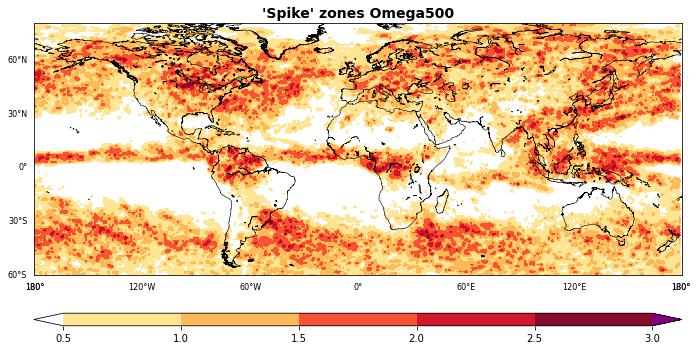

In [22]:
f()

plot(nansum(ME416C+ME421C+ME426C+ME506C+ME511C,2)/5,ME506P.lon,ME506P.lat,cmap=final_cmap,clf=arange(.5,3.1,.5),lon1=-180,lon2=180,lat1=-60,lat2=80);
plt.title("'Spike' zones Omega500", fontsize=14,fontweight='bold')
#plt.savefig('spike_zones_omg500.png',dpi=150)

In [142]:
# f()

# plot((ME416C+ME421C+ME426C+ME506C+ME511C)/5,ME506P.lon,ME506P.lat,cmap=discrete_cmap,clf=arange(1,4.1,.5),lon1=-180,lon2=180,lat1=-60,lat2=80);
# plt.title("'Spike' zones Omega500", fontsize=14,fontweight='bold')
# plt.savefig('spike_zones_omg500.png',dpi=150)

In [35]:
ME=(ME416C+ME421C+ME426C+ME506C+ME511C)/5

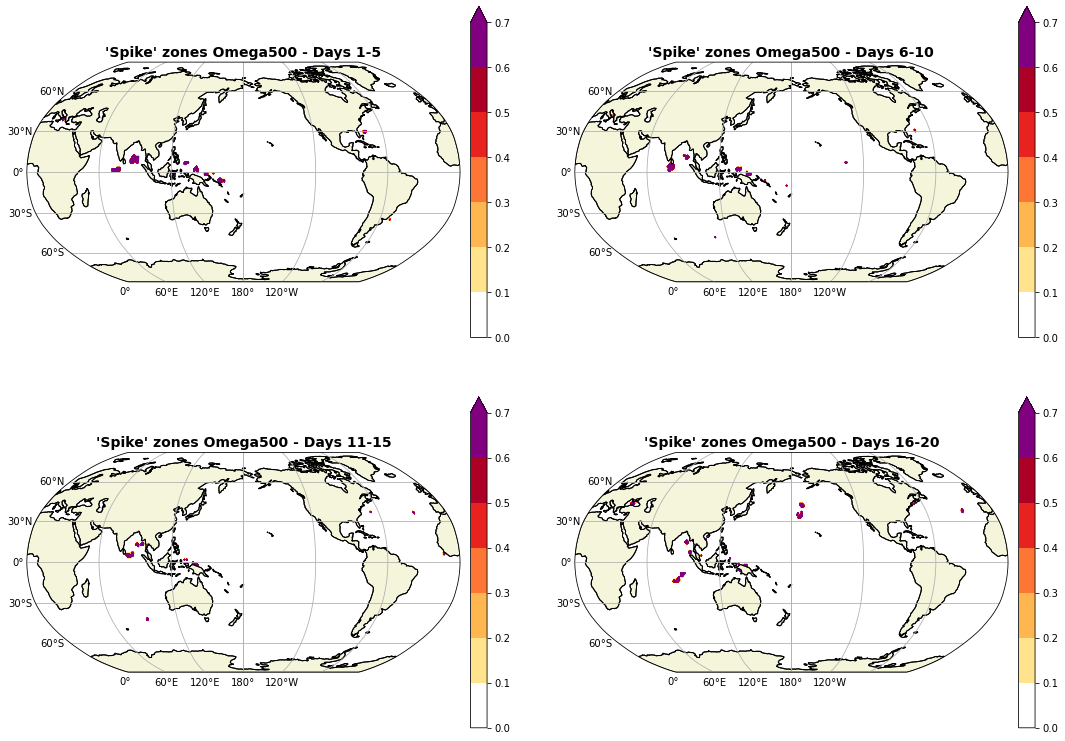

In [48]:
    period = 2  # 5-day interval = 4 (6-hourly points) * 5 (days)
    clf = arange(0, .71, .1)
    
    # Create a figure and a 2x2 grid of subplots
    fig, axes = plt.subplots(
        2, 2,
        figsize=(16, 12),
        subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}
    )
    axes_flat = axes.flatten()
    
    titles = [
        "'Spike' zones Omega500 - Days 1-5",
        "'Spike' zones Omega500 - Days 6-10",
        "'Spike' zones Omega500 - Days 11-15",
        "'Spike' zones Omega500 - Days 16-20"
    ]
    ds=ME#[:,:,5*4:]
    for i in range(4):
        start_index = i * period
        end_index = (i + 1) * period
        
        # Calculate the data for the current period
        data_to_plot = nansum(ds[:, :, start_index:end_index],2)
        
        # Call the plotting function for the current subplot
        plot_xr(
            data_to_plot,
            ME506P.lon,
            ME506P.lat,
            ax=axes_flat[i],
            projection_style='robinson',
            cmap=final_cmap,
            levels=clf,
            title=titles[i],
            add_gridlines=True, 
            central_longitude=180,
            add_land=True
        )
        
    plt.tight_layout(pad=3.0)
    plt.show()

/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/cartopy/crs.py:825: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  if len(multi_line_string) > 1:
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/cartopy/crs.py:877: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for line in multi_line_string:
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/cartopy/crs.py:944: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  i

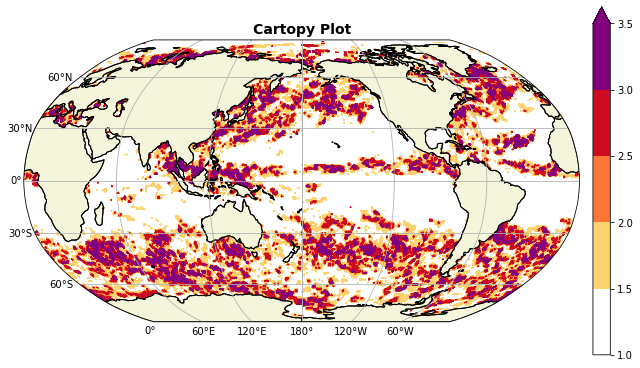

In [81]:
plot_xr(nansum(ME506C[:,:,:],2),lon,lat,central_longitude=180,cmap=final_cmap, add_land=True,levels=arange(1,3.71,.5),projection_style='robinson')

#plt.savefig('spike_zone_omg.png',dpi=150)

TypeError: Length of x (72) must match number of columns in z (360)

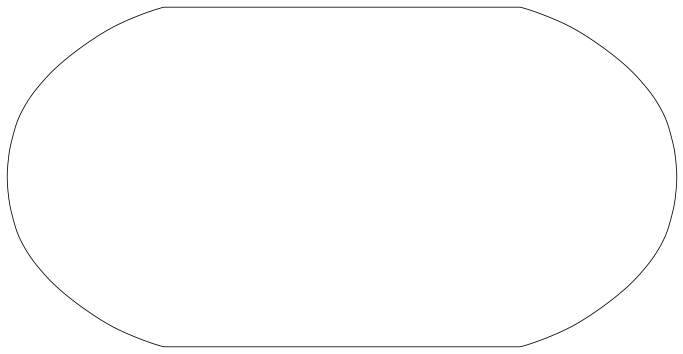

In [61]:
plot_xr(nansum(ME416C+ME421C+ME426C+ME506C+ME511C,2)/5,ME506P.lon,ME506P.lat,cmap=final_cmap,central_longitude=180, add_land=True,levels=arange(.5,3.1,.5),projection_style='robinson')

#plt.savefig('spike_zone_omg.png',dpi=150)

In [51]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from matplotlib.animation import FuncAnimation


In [89]:
ME=ME506C

Setting up dummy data with shape (181, 360, 256)...
Dummy data created.


/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/cartopy/crs.py:825: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  if len(multi_line_string) > 1:
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/cartopy/crs.py:877: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for line in multi_line_string:
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/cartopy/crs.py:944: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  i

Creating animation with 28 frames...
Saving animation as 'omega_spike_animation.gif'. This may take a moment...


/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:844: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  elif len(intersection) > 4:
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:850: ShapelyDeprecationWarning: __getitem__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  xy = np.append(intersection[0], intersection[-1],
<__array_function__ internals>:5: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/numpy/lib/functio


Animation saved successfully!


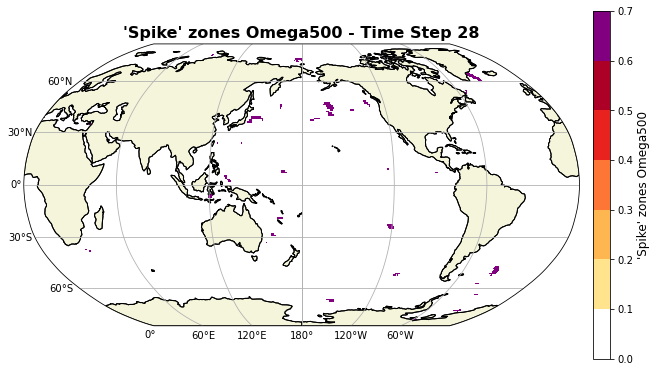

In [90]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from matplotlib.animation import FuncAnimation

# This script creates an animation from your time-series data.
# It uses an efficient method that updates the plot data for each frame
# rather than redrawing the entire plot.

if __name__ == '__main__':
    # --- ASSUMPTIONS & Example Setup ---
    # This script assumes you have your data loaded.
    # For this example, we create dummy data matching your specifications.
    
    # --- Create dummy data for demonstration ---
    print("Setting up dummy data with shape (181, 360, 256)...")
    lons = lon
    lats = lat
    time_len = 256
    shape = (len(lats), len(lons), time_len)
    
    # Create dummy ME data that changes over time
    time_coord = np.arange(time_len)
    lon_coord, lat_coord, time_coord_grid = np.meshgrid(lons, lats, time_coord, indexing='ij')
    # Create a pattern that moves diagonally over time
    #dummy_values = 0.35 * (1 + np.sin(2 * np.pi * (lon_coord_grid / 180 + time_coord_grid / 50.0)))
    #ME = xr.DataArray(dummy_values.transpose(1, 0, 2), dims=('lat', 'lon', 'time'))
    
    # Create dummy coordinate data
    #ME506P = xr.Dataset(coords={'lon': lons, 'lat': lats})
    #final_cmap = 'YlOrRd'
    #arange = np.arange
    print("Dummy data created.")

    # --- Animation Parameters ---
    num_frames_to_animate = 28
    clf = arange(0, .71, .1) # Levels for the colorbar

    # --- Set up the Figure and Axes for Animation ---
    # We create ONE figure and ONE axes that will be updated each frame.
    fig, ax = plt.subplots(
        1, 1,
        figsize=(12, 8),
        subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}
    )

    # --- Initial Plot Setup ---
    # Use the first time step of the data for the initial plot layout.
    initial_data = ME[:, :, 0]

    # Use BoundaryNorm for discrete color levels, which is required for pcolormesh
    norm = BoundaryNorm(clf, ncolors=plt.get_cmap(final_cmap, len(clf)-1).N, clip=True)

    # Create the pcolormesh object ONCE. This is the key to a fast animation.
    im = ax.pcolormesh(
        lon, lat, initial_data,
        cmap=final_cmap,
        norm=norm,
        transform=ccrs.PlateCarree()
    )

    # Add geographic features and gridlines ONCE.
    ax.add_feature(cfeature.LAND, zorder=1, edgecolor='k', facecolor='beige')
    ax.add_feature(cfeature.COASTLINE)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    ax.set_global()

    # Add the colorbar ONCE.
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
    cbar.set_label("'Spike' zones Omega500", fontsize=12)

    # Add a title object that we can update each frame.
    title_text = ax.set_title("", fontsize=16, fontweight='bold')

    # --- Animation Update Function ---
    def update(frame):
        """This function is called for each frame of the animation."""
        # Select the data for the current frame
        data_to_plot = ME[:, :, frame]
        
        # Update the data of the pcolormesh object. This is fast.
        # .ravel() flattens the 2D array, which is required by set_array.
        im.set_array(data_to_plot.ravel())
        
        # Update the title for the current frame
        title_text.set_text(f"'Spike' zones Omega500 - Time Step {frame + 1}")
        
        # Return the artists that have been updated
        return im, title_text

    # --- Create and Save the Animation ---
    print(f"Creating animation with {num_frames_to_animate} frames...")
    # interval=400 means 400 milliseconds between frames
    ani = FuncAnimation(fig, update, frames=num_frames_to_animate, interval=400, blit=False)

    try:
        # This requires an animation writer like 'imagemagick' or 'pillow'.
        # Pillow is often easier to install (`pip install pillow`).
        print("Saving animation as 'omega_spike_animation.gif'. This may take a moment...")
        ani.save('omega_spike_animation.gif', writer='pillow', fps=2.5)
        print("\nAnimation saved successfully!")
    except Exception as e:
        print(f"\nCould not save animation. An error occurred: {e}")
        print("Please ensure you have an animation writer installed, for example:\npip install pillow")

    # To display the animation in a popup window (e.g., in a script)
    # plt.show()


In [186]:
RP506P=RP506P.assign_coords(lon=RP506P.lon % 360).sortby('lon')

In [25]:
ME506P=ME506P.assign_coords(lon=ME506P.lon % 360).sortby('lon')

Text(0.5, 1.0, 'system travelling')

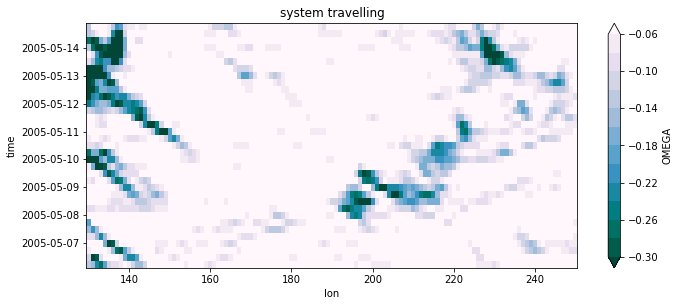

In [94]:
plt.figure(figsize=(11,4.5))
clf=arange(-.3,-.05,.02)
ME506P.sel(lat=slice(2,9),lon=slice(130,250),time=slice('2005-05-05','2005-05-14')).mean(dim='lat').plot(levels=clf,cmap='PuBuGn_r',)
plt.title('system travelling')

In [196]:
ME506Pa=ME506P-ME506P.mean(dim='time')

Text(0.5, 1.0, 'system travelling')

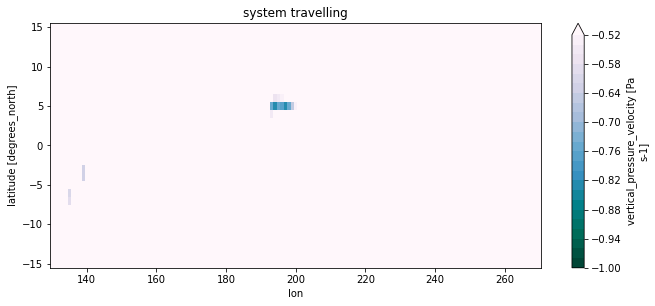

In [375]:
plt.figure(figsize=(11,4.5))
clf=arange(-1,-.51,.02)
(ME506P.sel(lat=slice(-15,15),lon=slice(130,270))[8,:,:]).plot(levels=clf,cmap='PuBuGn_r')
plt.title('system travelling')
#plt.xticks(ds.lon[::20].data,["140°E", "160°E", "180°E", "160°W", "140°W", "120°W",  "100°W"]);

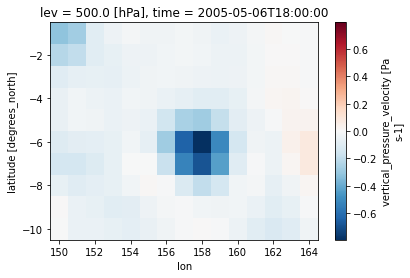

In [351]:
ME506P[2,80:90,150:165].plot()#.mean(dim='lat')

In [353]:
ds[2,10:20]

<xarray.DataArray 'OMEGA' (lon: 10)>
array([-0.04680557, -0.10796285, -0.11608912, -0.13044283, -0.15190908,
       -0.12959927, -0.0800304 , -0.02326104, -0.00716491, -0.03358585],
      dtype=float32)
Coordinates:
  * lon      (lon) float64 150.0 151.0 152.0 153.0 ... 156.0 157.0 158.0 159.0
    lev      float64 500.0
    time     datetime64[ns] 2005-05-06T18:00:00

In [376]:
ds.data[2:8,10:20]=ME506P[2:8,80:90,150:160].mean(dim='lat').data

In [378]:
ds1=ME506P.sel(lat=slice(-10,-10),lon=slice(140,260),time=slice('2005-05-05','2005-05-14')).mean(dim='lat')
ds2=ME506P.sel(lat=slice(2,8),lon=slice(140,260),time=slice('2005-05-05','2005-05-14')).mean(dim='lat')
ds= (ds1+ds2)

In [379]:
ds.data[24,85:95]=ME506P[29,97:101,225:235].mean(dim='lat').data

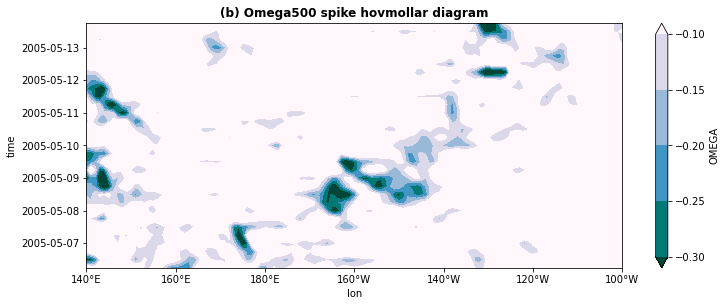

In [380]:
plt.figure(figsize=(12,4.5))
clf=arange(-.3,-.05,.05)
ds.sel(time=slice('2005-05-05','2005-05-13')).plot.contourf(levels=clf,cmap='PuBuGn_r',)
plt.title('(b) Omega500 spike hovmollar diagram',fontsize=12,fontweight='bold')
plt.xticks(ds.lon[::20].data,["140°E", "160°E", "180°E", "160°W", "140°W", "120°W",  "100°W"]);
plt.savefig('hovmollar.png',dpi=200)

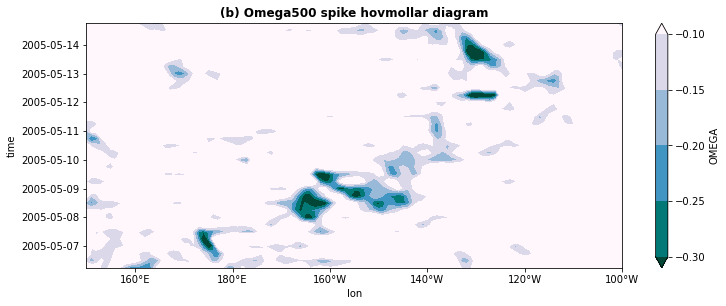

In [382]:
plt.figure(figsize=(12,4.5))
clf=arange(-.3,-.05,.05)
ds.sel(time=slice('2005-05-05','2005-05-14'),lon=slice(150,260)).plot.contourf(levels=clf,cmap='PuBuGn_r',)
plt.title('(b) Omega500 spike hovmollar diagram',fontsize=12,fontweight='bold')
plt.xticks(ds.sel(lon=slice(150,260)).lon[10::20].data,["160°E", "180°E", "160°W", "140°W", "120°W",  "100°W"]);
plt.savefig('hovmollar.png',dpi=200)

In [383]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, to_rgba

# Step 1: Get the base colors from 'CMRmap_r'
num_colors = 12
cmap = plt.get_cmap('YlOrRd', num_colors)
colors = cmap(np.arange(num_colors))[2:]
#colors=np.vstack((colors[:4],colors[9:]))
# Step 2: Define 'brown' and get its RGBA value
# The color needs to be in a 2D array to be stacked.
red_rgba = np.array([to_rgba('red')])
pu_rgba = np.array([to_rgba('purple')])
brown_rgba = np.array([to_rgba('black')])
white_rgba = np.array([to_rgba('white')])
br_rgba = np.array([to_rgba('brown')])

# Step 3: Append brown to the end of the color list
all_colors = np.vstack((white_rgba,  pu_rgba,red_rgba, br_rgba, brown_rgba ))#, brown_rgba))

# Step 4: Create the new colormap from the combined list
cmap1 = ListedColormap(all_colors)

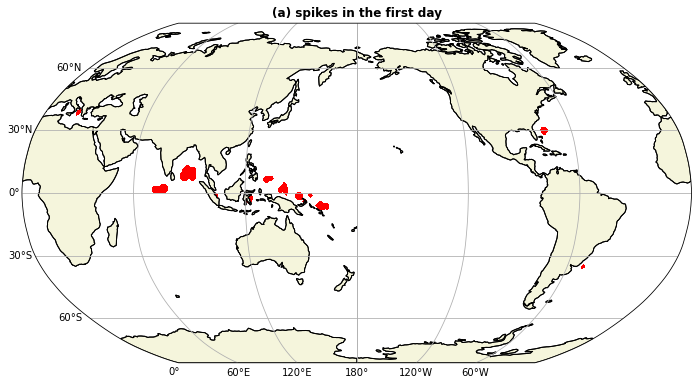

In [403]:
# fig, axes = plt.subplots(
#         1, 1,
#         figsize=(12, 8.5),
#         subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}
#     )
# axes_flat = axes.flatten()
clf = array([0,1])#arange(0, 3, .5)
plot_xr(nansum(ME506C[:,:,:2],2),
        ME506P.lon,
        ME506P.lat,
        projection_style='robinson',
        cmap=cmap1,
        levels=clf,
        title='(a) spikes in the first day',
        add_gridlines=True, 
        central_longitude=180,
        add_land=True,
        
        )

plt.savefig('initial_spike.png',dpi=200)